Loading real data
Loading synthetic data

Real X: (46907, 512, 6)
Synthetic X: (46907, 512, 6)

Available real subjects:
['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

Available synthetic subjects:
['SYN_001', 'SYN_002', 'SYN_003', 'SYN_004', 'SYN_005', 'SYN_006', 'SYN_007', 'SYN_008', 'SYN_009', 'SYN_010', 'SYN_011', 'SYN_012', 'SYN_013', 'SYN_014', 'SYN_015', 'SYN_016', 'SYN_017', 'SYN_018', 'SYN_019', 'SYN_020']

Reconstructing REAL SPACED subject: S1
Real spaced windows: (3445, 512, 6)
Real spaced continuous: (568960, 6)
Real spaced duration min: 148.16666666666666
Real spaced label counts: {np.int64(1): np.int64(347), np.int64(2): np.int64(141), np.int64(3): np.int64(170), np.int64(4): np.int64(203), np.int64(5): np.int64(442), np.int64(6): np.int64(1175), np.int64(7): np.int64(375), np.int64(8): np.int64(592)}


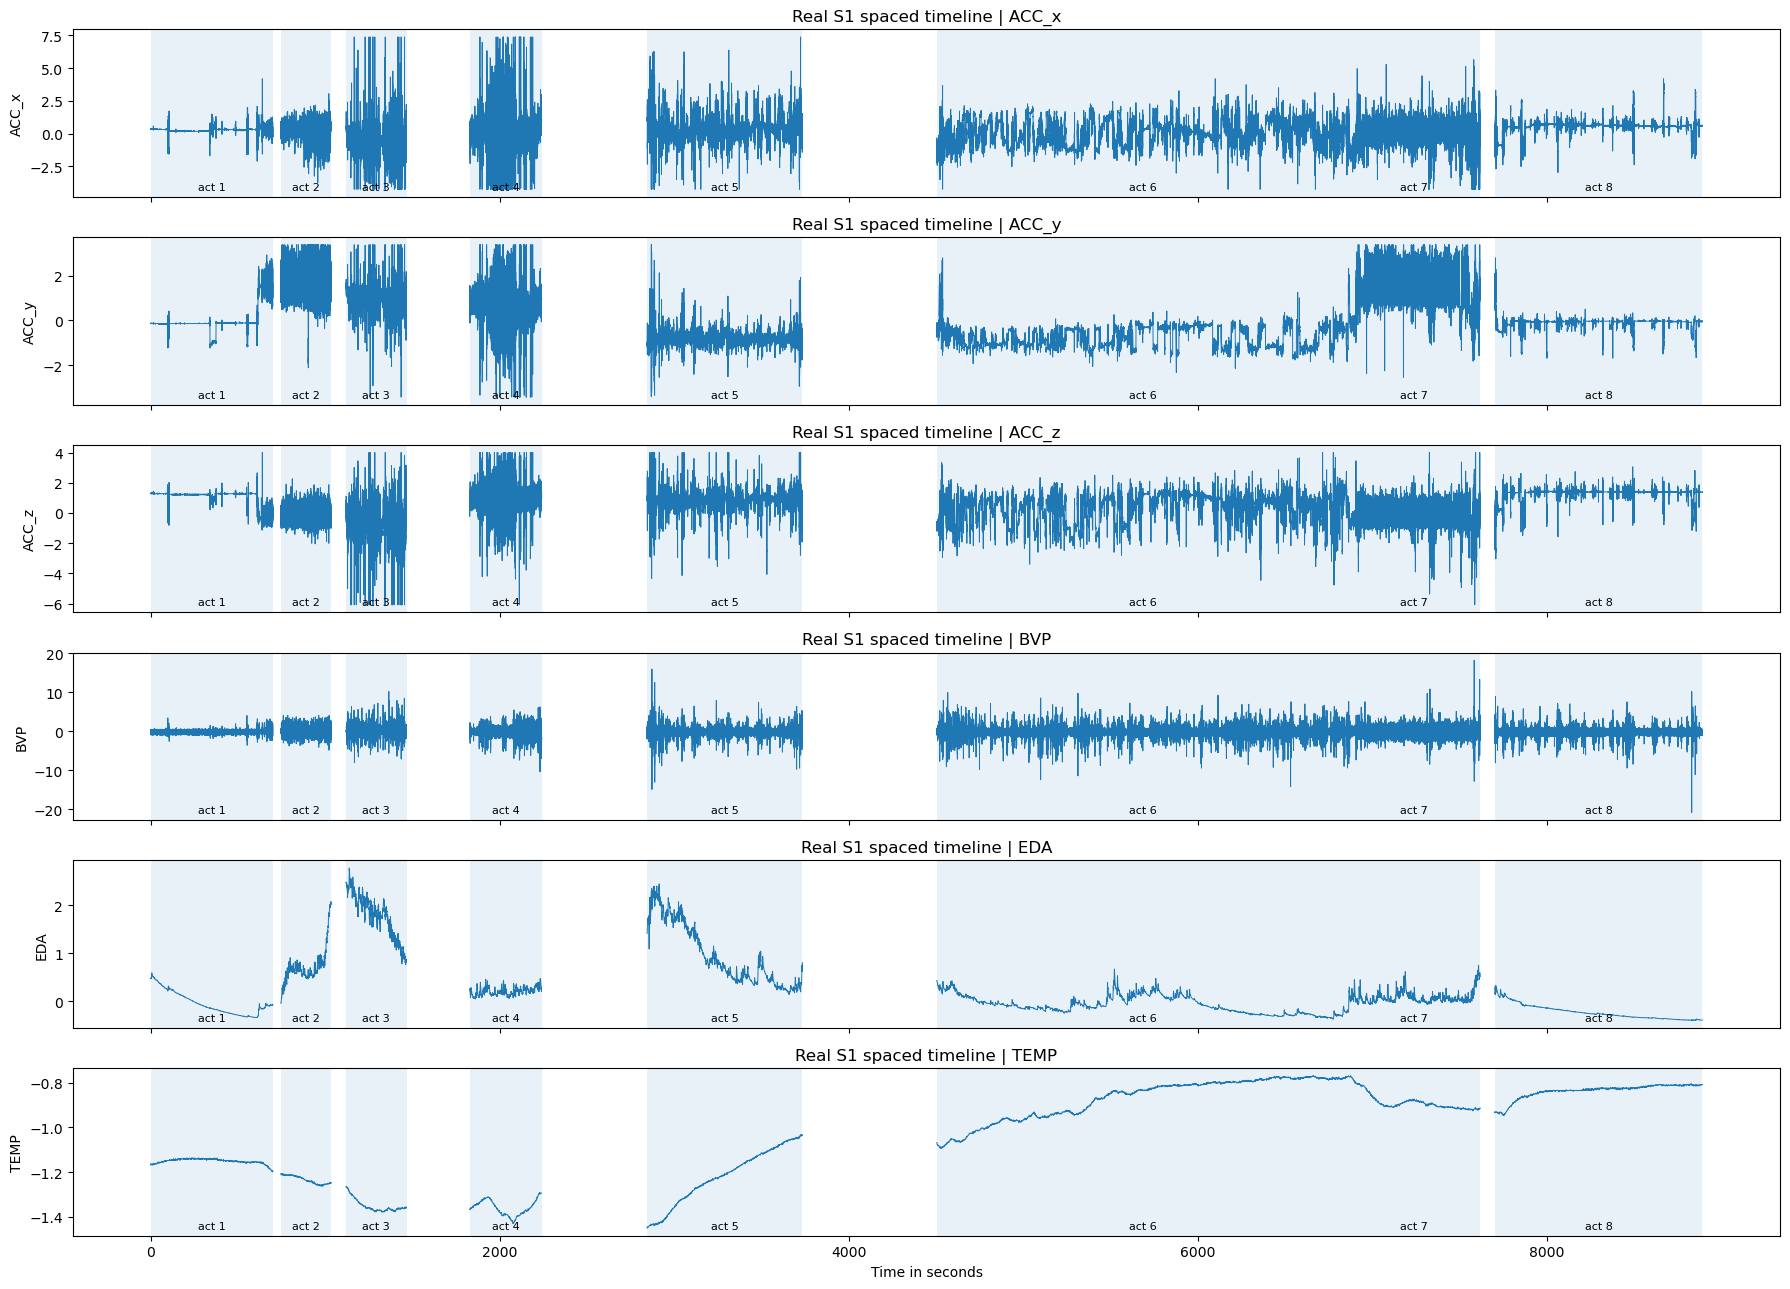


Reconstructing REAL STITCHED subject: S1
Real stitched windows: (3445, 512, 6)
Real stitched continuous: (441344, 6)
Real stitched duration min: 114.93333333333334
Real stitched label counts: {np.int64(1): np.int64(347), np.int64(2): np.int64(141), np.int64(3): np.int64(170), np.int64(4): np.int64(203), np.int64(5): np.int64(442), np.int64(6): np.int64(1175), np.int64(7): np.int64(375), np.int64(8): np.int64(592)}


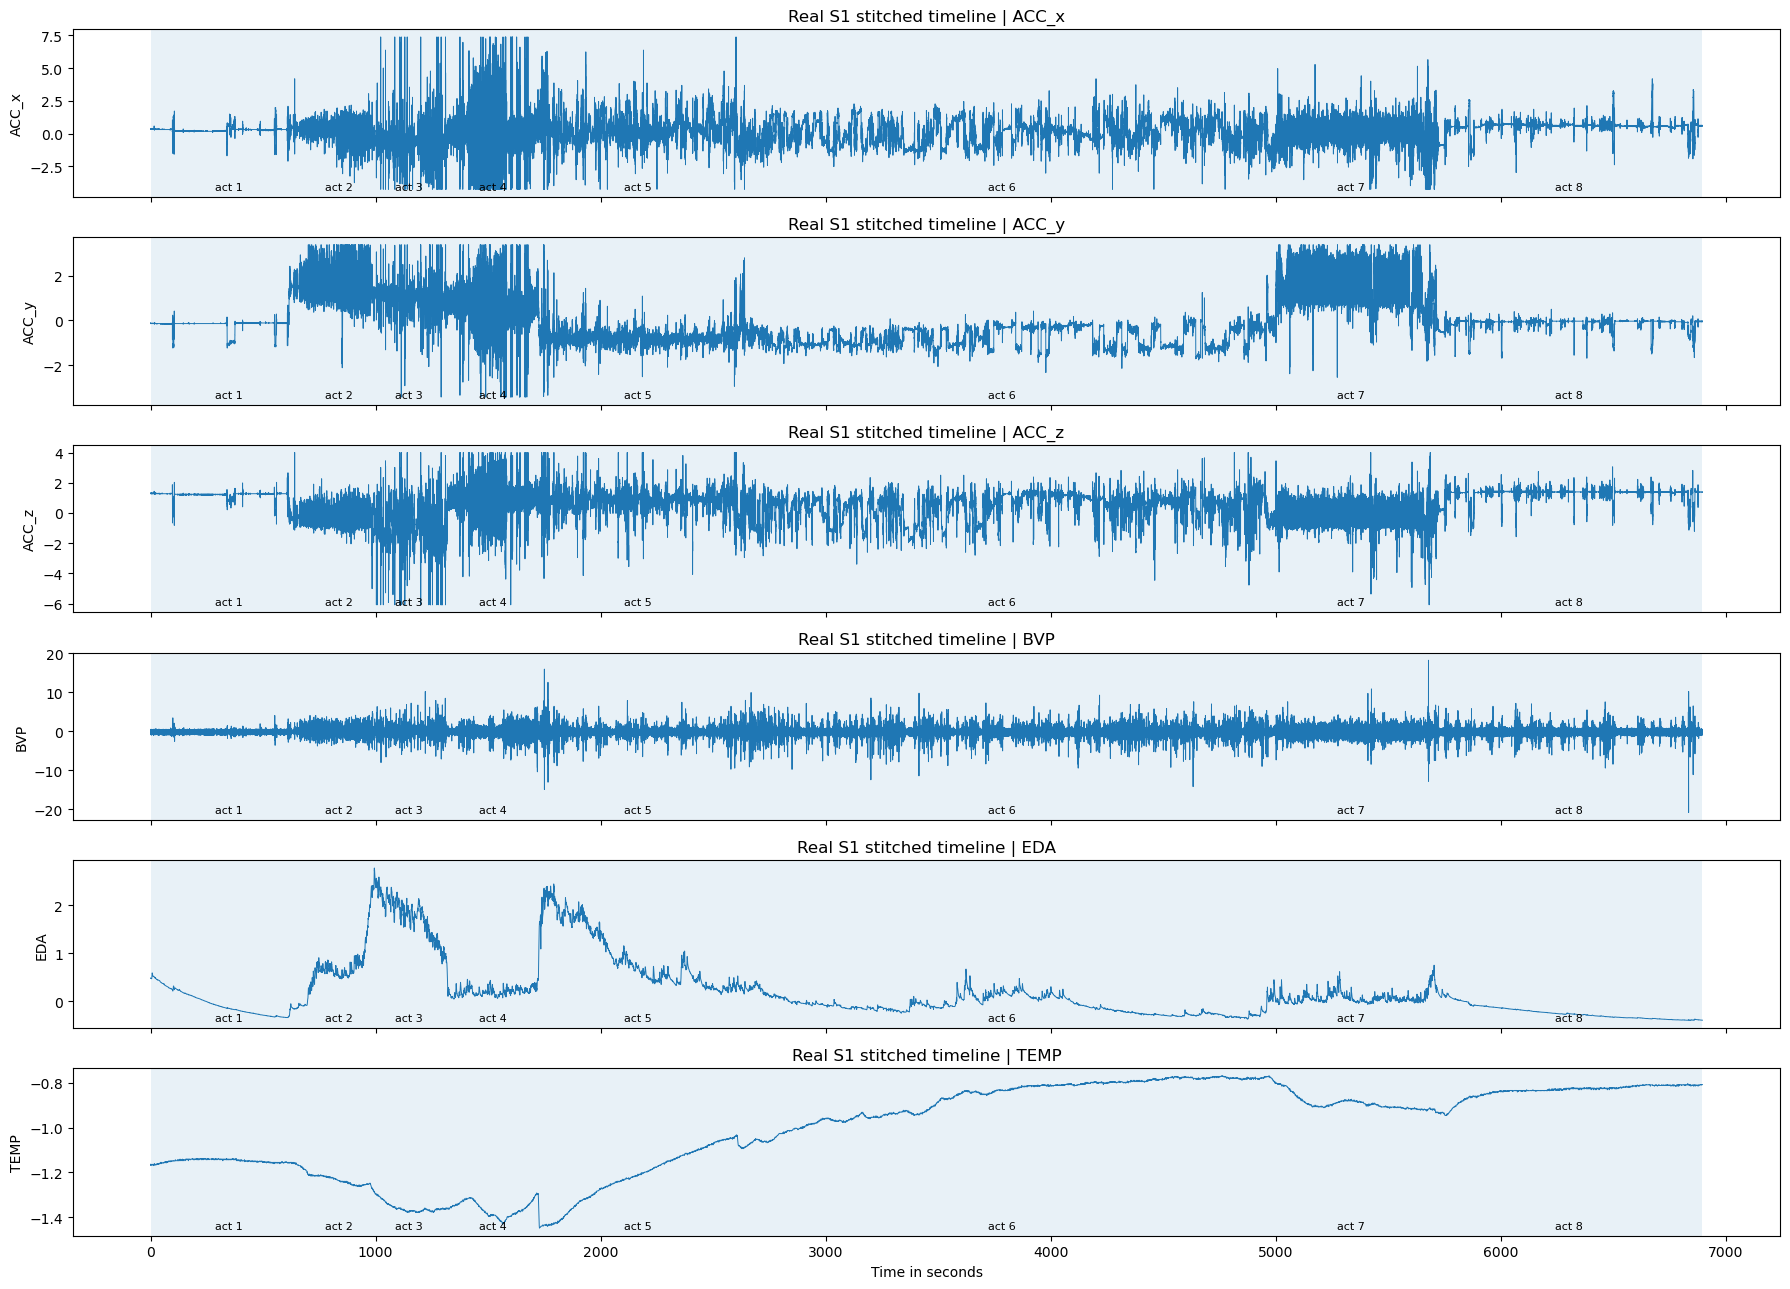


Reconstructing SYNTHETIC subject: SYN_001
Synthetic windows: (1524, 512, 6)
Synthetic continuous: (195456, 6)
Synthetic duration min: 50.9
Synthetic label counts: {np.int64(1): np.int64(146), np.int64(2): np.int64(97), np.int64(3): np.int64(77), np.int64(4): np.int64(107), np.int64(5): np.int64(225), np.int64(6): np.int64(451), np.int64(7): np.int64(145), np.int64(8): np.int64(276)}


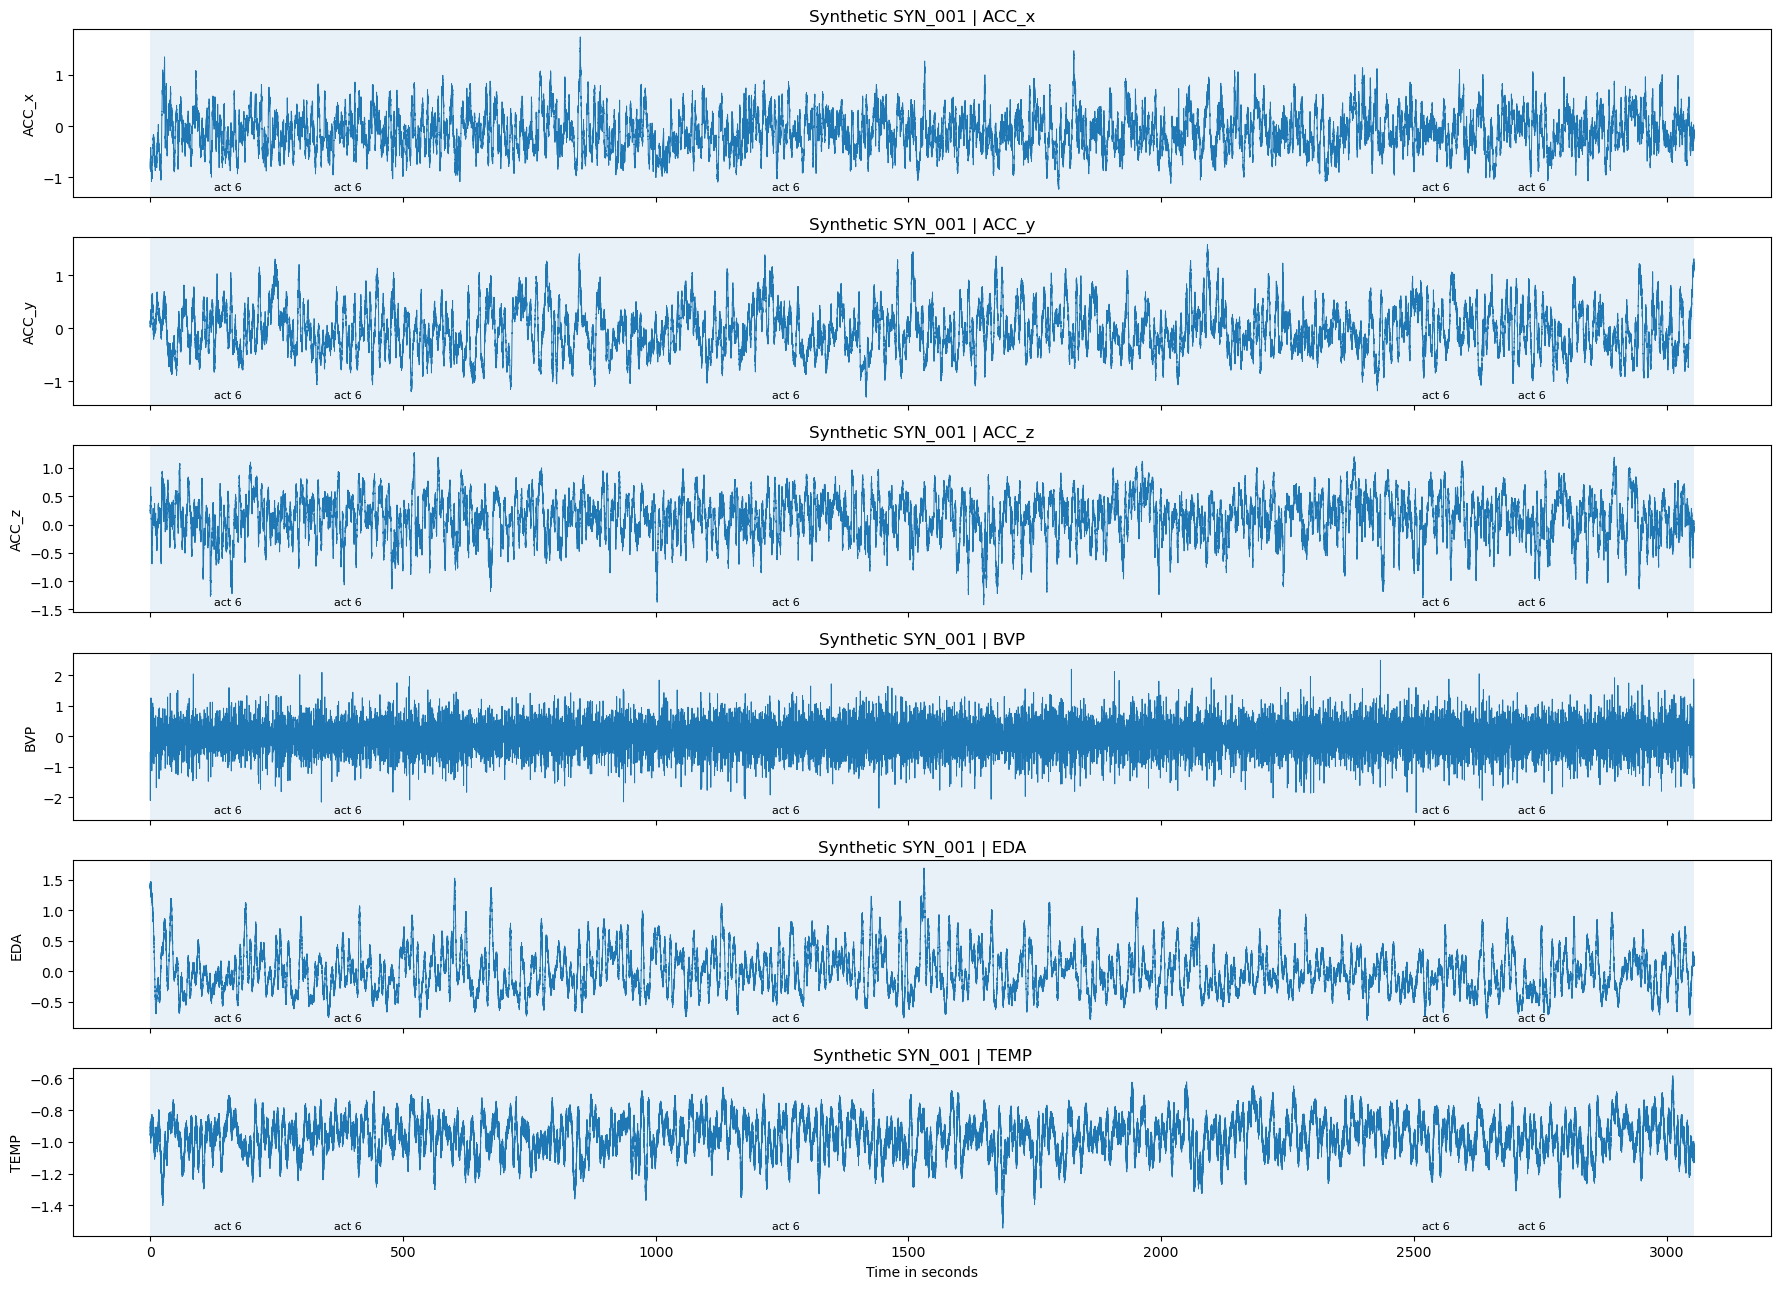


Three-way channel comparison


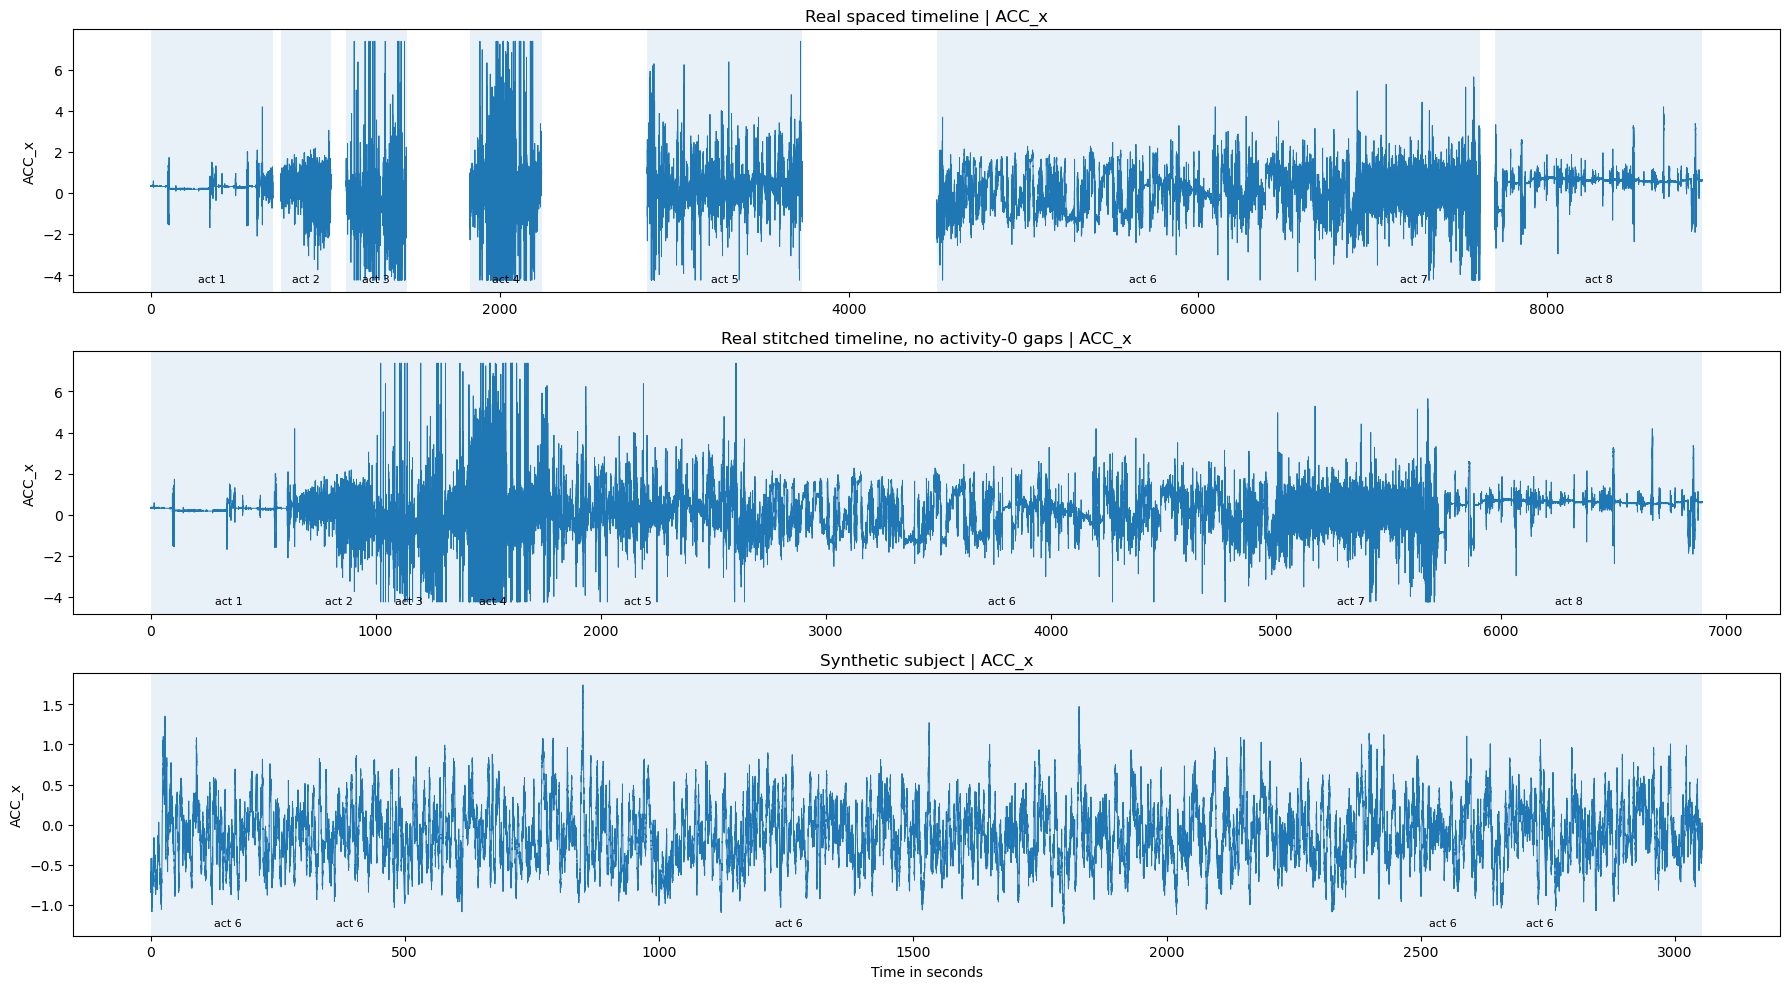

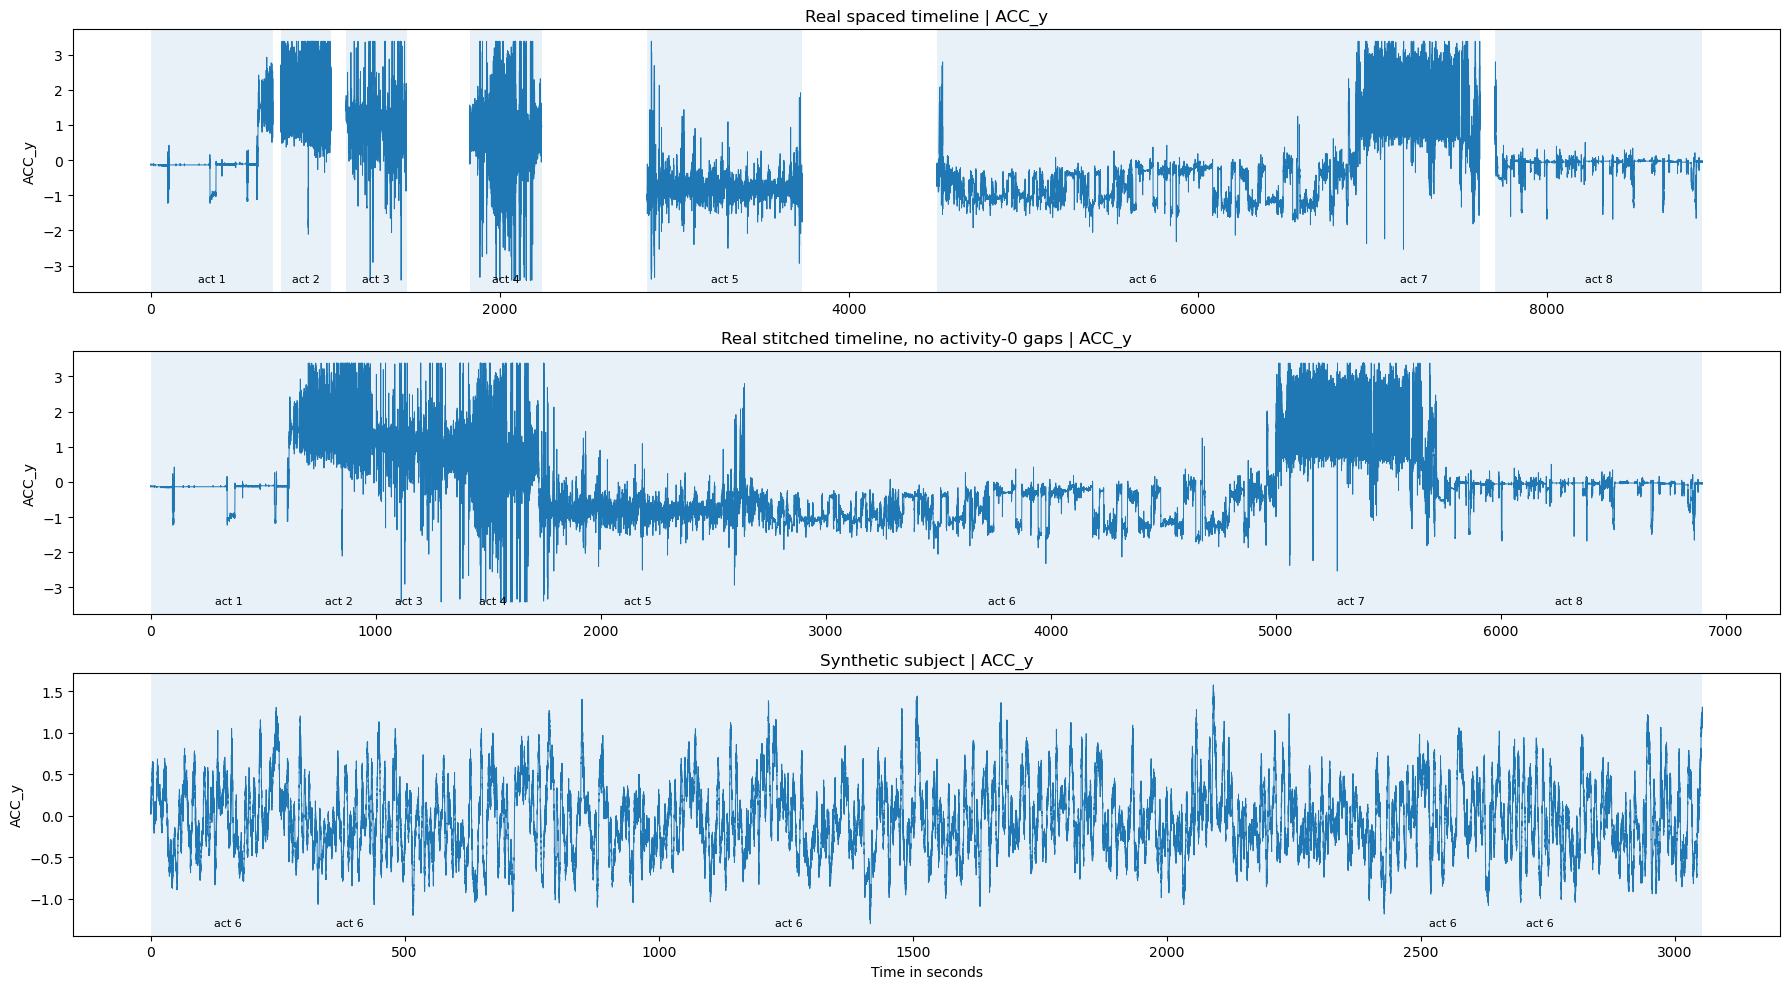

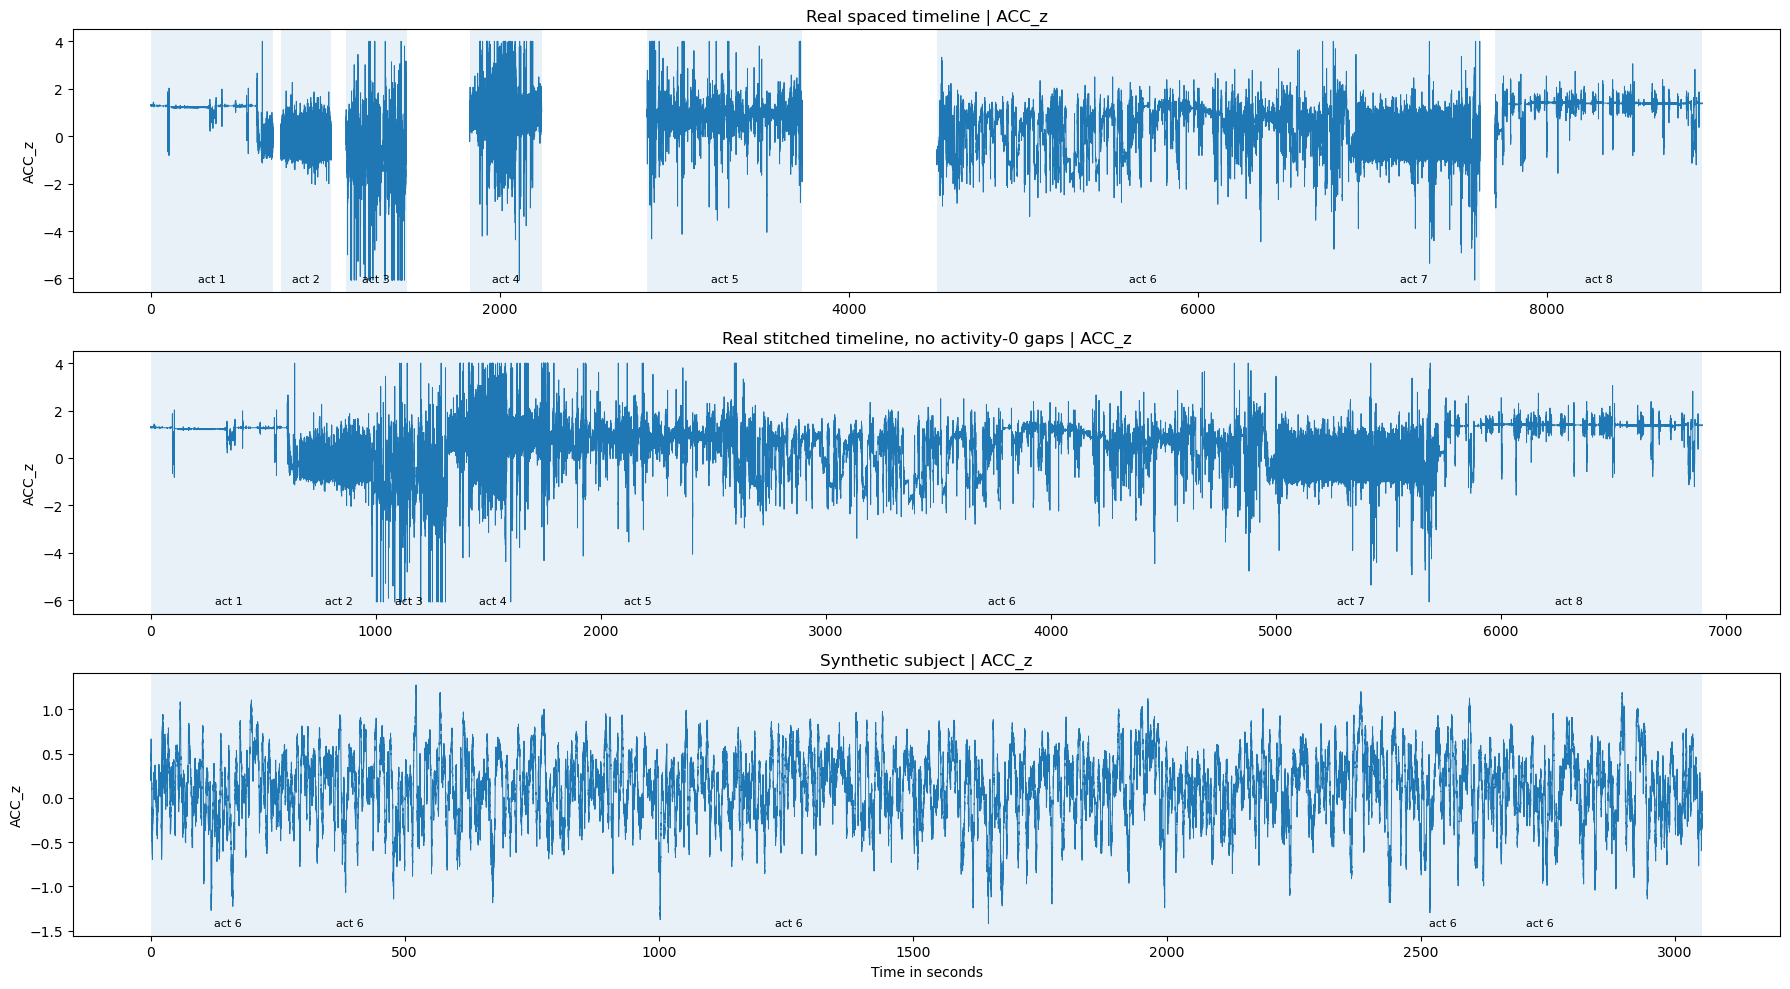

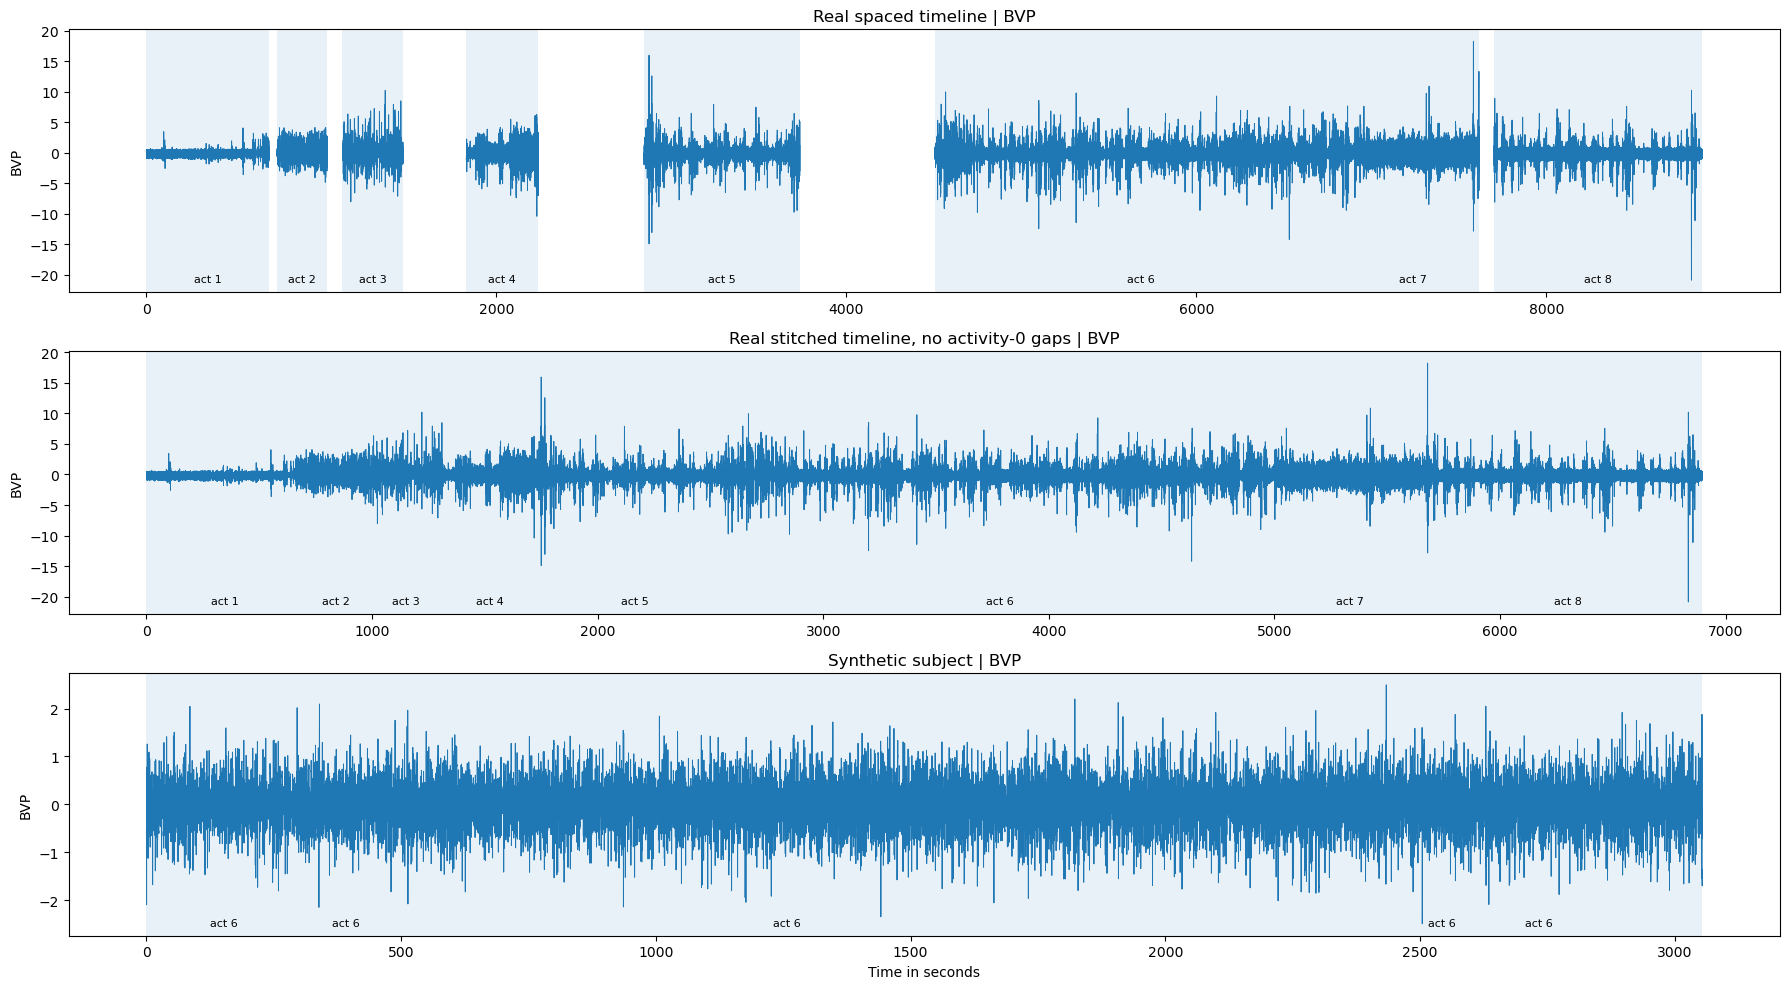

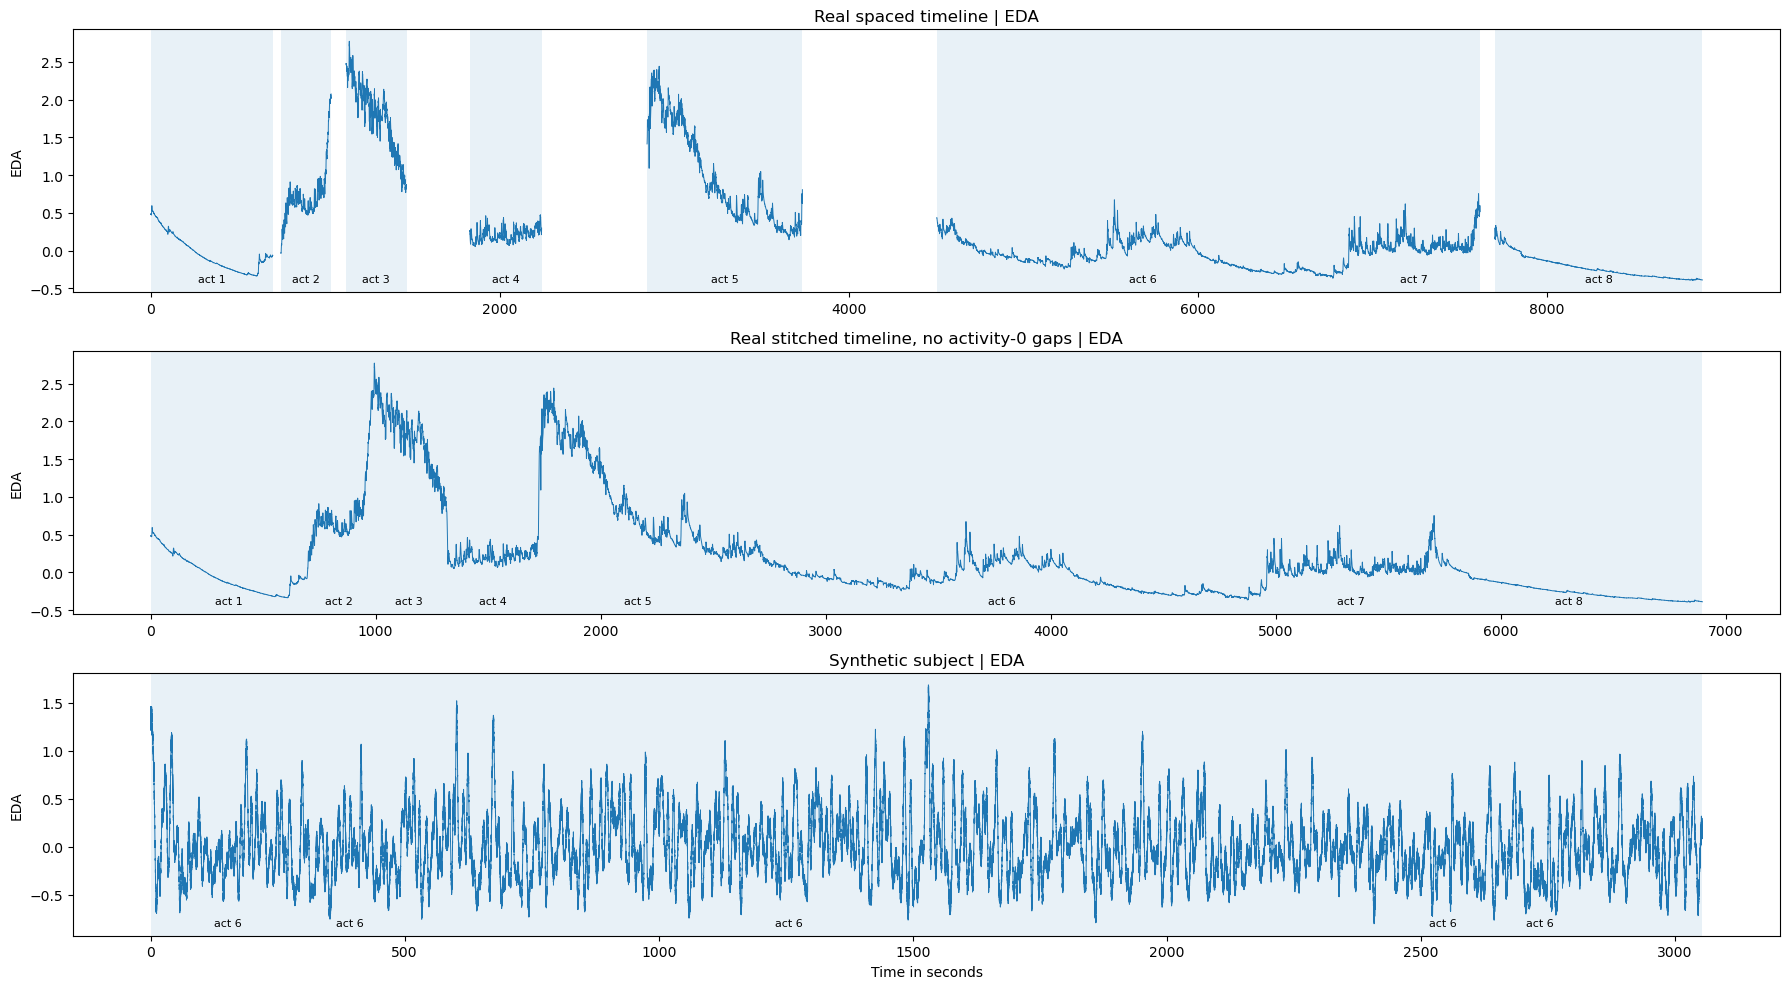

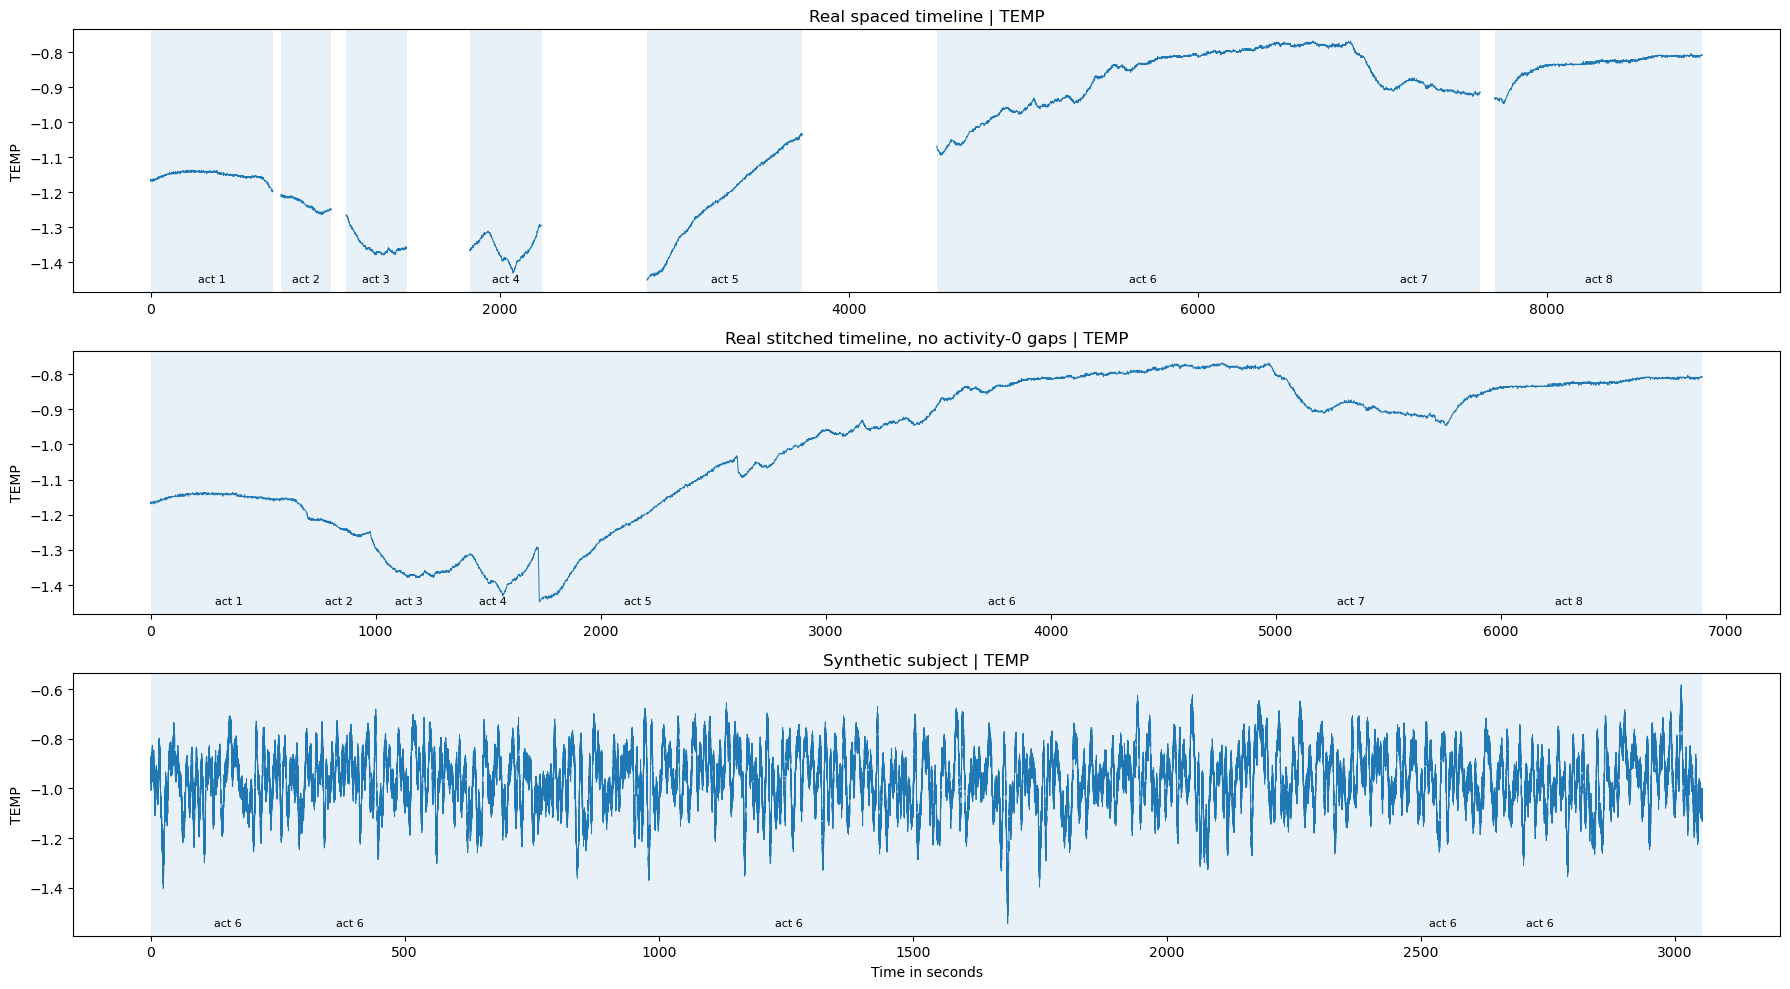


Done.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Paths for your project
# ============================================================

PROJECT_ROOT = Path("/home/iailab42/khans1/projects")

REAL_DIR = PROJECT_ROOT / "data"
SYN_DIR = PROJECT_ROOT / "data" / "synthetic"

REAL_X_PATH = REAL_DIR / "all_X.npy"
REAL_Y_PATH = REAL_DIR / "all_y.npy"
REAL_SUBJECT_PATH = REAL_DIR / "all_subject.npy"
REAL_METADATA_PATH = REAL_DIR / "all_metadata.csv"

# SYN_X_PATH = SYN_DIR / "all_X_synthetic.npy"
# SYN_Y_PATH = SYN_DIR / "all_y_synthetic.npy"
# SYN_SUBJECT_PATH = SYN_DIR / "all_subject_synthetic.npy"
# SYN_METADATA_PATH = SYN_DIR / "all_metadata_synthetic.csv"

SYN_X_PATH = SYN_DIR / "timevae"/ "all_X_synthetic.npy"
SYN_Y_PATH = SYN_DIR / "timevae"/ "all_y_synthetic.npy"
SYN_SUBJECT_PATH = SYN_DIR / "timevae"/ "all_subject_synthetic.npy"
SYN_METADATA_PATH = SYN_DIR / "timevae"/ "all_metadata_synthetic.csv"
# OUT_DIR = PROJECT_ROOT / "figures" / "comparison"
# OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Constants
# ============================================================

TARGET_HZ = 64
WINDOW_LEN = 512
SHIFT_LEN = 128

CHANNEL_NAMES = ["ACC_x", "ACC_y", "ACC_z", "BVP", "EDA", "TEMP"]
NUM_CHANNELS = len(CHANNEL_NAMES)

REAL_SUBJECT_TO_PLOT = "S1"
SYN_SUBJECT_TO_PLOT = "SYN_001"

WEIGHT_MODE = "hann"
PLOT_STEP = 1


# ============================================================
# Helpers
# ============================================================

def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return path


def check_window_shape(X, expected_channels, name):
    if X.ndim != 3:
        raise ValueError(f"{name}: expected [N, T, C], got {X.shape}")
    if X.shape[1] != WINDOW_LEN:
        raise ValueError(f"{name}: expected window length {WINDOW_LEN}, got {X.shape[1]}")
    if X.shape[2] != expected_channels:
        raise ValueError(f"{name}: expected {expected_channels} channels, got {X.shape[2]}")


def load_real_data():
    require_file(REAL_X_PATH)
    require_file(REAL_Y_PATH)
    require_file(REAL_SUBJECT_PATH)
    require_file(REAL_METADATA_PATH)

    X = np.load(REAL_X_PATH).astype(np.float32)
    y = np.load(REAL_Y_PATH).astype(np.int64)
    subjects = np.load(REAL_SUBJECT_PATH, allow_pickle=True).astype(str)
    metadata = pd.read_csv(REAL_METADATA_PATH)

    check_window_shape(X, NUM_CHANNELS, "Real X")

    metadata = metadata.copy()
    metadata["subject"] = subjects
    metadata["activity_label"] = y
    metadata["array_index"] = np.arange(len(y), dtype=np.int64)

    return X, y, subjects, metadata


def load_synthetic_data():
    require_file(SYN_X_PATH)
    require_file(SYN_Y_PATH)
    require_file(SYN_SUBJECT_PATH)
    require_file(SYN_METADATA_PATH)

    X = np.load(SYN_X_PATH).astype(np.float32)
    y = np.load(SYN_Y_PATH).astype(np.int64)
    subjects = np.load(SYN_SUBJECT_PATH, allow_pickle=True).astype(str)
    metadata = pd.read_csv(SYN_METADATA_PATH)

    check_window_shape(X, NUM_CHANNELS, "Synthetic X")

    metadata = metadata.copy()
    metadata["synthetic_subject"] = subjects
    metadata["activity_label"] = y
    metadata["array_index"] = np.arange(len(y), dtype=np.int64)

    return X, y, subjects, metadata


def make_window_weights(window_len, weight_mode="hann"):
    if weight_mode == "hann":
        weights = np.hanning(window_len).astype(np.float32)
        weights = np.maximum(weights, 1e-3)
    elif weight_mode == "ones":
        weights = np.ones(window_len, dtype=np.float32)
    else:
        raise ValueError("weight_mode must be 'hann' or 'ones'.")
    return weights[:, None]


def reconstruct_overlap_add(
    windows,
    labels,
    start_samples,
    end_samples,
    window_len=WINDOW_LEN,
    weight_mode=WEIGHT_MODE,
):
    windows = np.asarray(windows, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.int64)
    start_samples = np.asarray(start_samples, dtype=np.int64)
    end_samples = np.asarray(end_samples, dtype=np.int64)

    offset = int(start_samples.min())
    start_samples = start_samples - offset
    end_samples = end_samples - offset

    total_len = int(end_samples.max())
    num_channels = windows.shape[2]

    continuous_sum = np.zeros((total_len, num_channels), dtype=np.float32)
    weight_sum = np.zeros((total_len, 1), dtype=np.float32)

    max_label = max(8, int(labels.max()))
    label_scores = np.zeros((total_len, max_label + 1), dtype=np.float32)

    win_weight = make_window_weights(window_len, weight_mode)

    for i in range(len(windows)):
        s = int(start_samples[i])
        e = int(end_samples[i])

        if e <= s:
            continue

        if e - s != window_len:
            raise ValueError(f"Window {i} has length {e - s}, expected {window_len}.")

        continuous_sum[s:e] += windows[i] * win_weight
        weight_sum[s:e] += win_weight

        lab = int(labels[i])
        if 0 <= lab < label_scores.shape[1]:
            label_scores[s:e, lab] += win_weight[:, 0]

    covered = weight_sum[:, 0] > 1e-8

    continuous = np.full_like(continuous_sum, np.nan, dtype=np.float32)
    continuous[covered] = continuous_sum[covered] / weight_sum[covered]

    sample_labels = np.zeros(total_len, dtype=np.int64)
    sample_labels[covered] = np.argmax(label_scores[covered], axis=1)

    coverage = weight_sum[:, 0]

    return continuous, sample_labels, coverage


def get_real_subject_windows_spaced(X, metadata, subject_name):
    sub = metadata[metadata["subject"] == subject_name].copy()
    if len(sub) == 0:
        raise ValueError(f"Real subject {subject_name} not found.")
    sub = sub.sort_values("start_sample_64hz").reset_index(drop=True)

    idxs = sub["array_index"].to_numpy(dtype=np.int64)
    windows = X[idxs]
    labels = sub["activity_label"].to_numpy(dtype=np.int64)
    start_samples = sub["start_sample_64hz"].to_numpy(dtype=np.int64)
    end_samples = sub["end_sample_64hz"].to_numpy(dtype=np.int64)

    return windows, labels, start_samples, end_samples, sub


def get_real_subject_windows_stitched(X, metadata, subject_name):
    sub = metadata[metadata["subject"] == subject_name].copy()
    if len(sub) == 0:
        raise ValueError(f"Real subject {subject_name} not found.")
    sub = sub.sort_values("start_sample_64hz").reset_index(drop=True)

    idxs = sub["array_index"].to_numpy(dtype=np.int64)
    windows = X[idxs]
    labels = sub["activity_label"].to_numpy(dtype=np.int64)

    start_samples = np.arange(len(sub), dtype=np.int64) * SHIFT_LEN
    end_samples = start_samples + WINDOW_LEN

    return windows, labels, start_samples, end_samples, sub


def get_synthetic_subject_windows(X, metadata, subject_name):
    sub = metadata[metadata["synthetic_subject"] == subject_name].copy()
    if len(sub) == 0:
        available = sorted(metadata["synthetic_subject"].unique().tolist())
        raise ValueError(f"Synthetic subject {subject_name} not found. Available: {available[:20]}")

    if "synthetic_window_in_subject" in sub.columns:
        sub = sub.sort_values("synthetic_window_in_subject").reset_index(drop=True)
    else:
        sub = sub.sort_values("start_sample_64hz").reset_index(drop=True)

    idxs = sub["array_index"].to_numpy(dtype=np.int64)
    windows = X[idxs]
    labels = sub["activity_label"].to_numpy(dtype=np.int64)
    start_samples = sub["start_sample_64hz"].to_numpy(dtype=np.int64)
    end_samples = sub["end_sample_64hz"].to_numpy(dtype=np.int64)

    return windows, labels, start_samples, end_samples, sub


def activity_segments(sample_labels):
    labels = np.asarray(sample_labels, dtype=np.int64)
    if len(labels) == 0:
        return []

    segments = []
    start = 0
    current = int(labels[0])

    for i in range(1, len(labels)):
        lab = int(labels[i])
        if lab != current:
            segments.append((start, i, current))
            start = i
            current = lab

    segments.append((start, len(labels), current))
    return segments


def add_activity_background(ax, sample_labels, target_hz=TARGET_HZ):
    ymin, ymax = ax.get_ylim()
    if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin == ymax:
        return

    y_text = ymin + 0.03 * (ymax - ymin)

    for start, end, lab in activity_segments(sample_labels):
        if lab == 0:
            continue

        start_sec = start / float(target_hz)
        end_sec = end / float(target_hz)

        ax.axvspan(start_sec, end_sec, alpha=0.10)

        if end_sec - start_sec >= 10:
            ax.text(
                (start_sec + end_sec) / 2.0,
                y_text,
                f"act {lab}",
                ha="center",
                va="bottom",
                fontsize=8,
            )


def decimate_for_plot(time_sec, signal, labels, step):
    if step <= 1:
        return time_sec, signal, labels
    return time_sec[::step], signal[::step], labels[::step]


def plot_one_continuous_subject(
    continuous,
    sample_labels,
    title,
    target_hz=TARGET_HZ,
):
    time_sec = np.arange(len(continuous)) / float(target_hz)
    time_plot, cont_plot, labels_plot = decimate_for_plot(
        time_sec,
        continuous,
        sample_labels,
        PLOT_STEP,
    )

    fig, axes = plt.subplots(
        len(CHANNEL_NAMES),
        1,
        figsize=(18, 13),
        sharex=True,
    )

    for c, name in enumerate(CHANNEL_NAMES):
        ax = axes[c]
        ax.plot(time_plot, cont_plot[:, c], linewidth=0.7)
        ax.set_ylabel(name)
        ax.set_title(f"{title} | {name}")
        add_activity_background(ax, labels_plot, target_hz=target_hz / PLOT_STEP)

    axes[-1].set_xlabel("Time in seconds")
    plt.tight_layout()
    plt.show()


def plot_three_way_channel(
    real_spaced_cont,
    real_spaced_labels,
    real_stitched_cont,
    real_stitched_labels,
    syn_cont,
    syn_labels,
    channel_name,
    target_hz=TARGET_HZ,
):
    c = CHANNEL_NAMES.index(channel_name)

    real_spaced_time = np.arange(len(real_spaced_cont)) / float(target_hz)
    real_stitched_time = np.arange(len(real_stitched_cont)) / float(target_hz)
    syn_time = np.arange(len(syn_cont)) / float(target_hz)

    real_spaced_time_plot, real_spaced_cont_plot, real_spaced_labels_plot = decimate_for_plot(
        real_spaced_time,
        real_spaced_cont,
        real_spaced_labels,
        PLOT_STEP,
    )

    real_stitched_time_plot, real_stitched_cont_plot, real_stitched_labels_plot = decimate_for_plot(
        real_stitched_time,
        real_stitched_cont,
        real_stitched_labels,
        PLOT_STEP,
    )

    syn_time_plot, syn_cont_plot, syn_labels_plot = decimate_for_plot(
        syn_time,
        syn_cont,
        syn_labels,
        PLOT_STEP,
    )

    fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=False)

    axes[0].plot(real_spaced_time_plot, real_spaced_cont_plot[:, c], linewidth=0.7)
    axes[0].set_title(f"Real spaced timeline | {channel_name}")
    axes[0].set_ylabel(channel_name)
    add_activity_background(axes[0], real_spaced_labels_plot, target_hz=target_hz / PLOT_STEP)

    axes[1].plot(real_stitched_time_plot, real_stitched_cont_plot[:, c], linewidth=0.7)
    axes[1].set_title(f"Real stitched timeline, no activity-0 gaps | {channel_name}")
    axes[1].set_ylabel(channel_name)
    add_activity_background(axes[1], real_stitched_labels_plot, target_hz=target_hz / PLOT_STEP)

    axes[2].plot(syn_time_plot, syn_cont_plot[:, c], linewidth=0.7)
    axes[2].set_title(f"Synthetic subject | {channel_name}")
    axes[2].set_ylabel(channel_name)
    axes[2].set_xlabel("Time in seconds")
    add_activity_background(axes[2], syn_labels_plot, target_hz=target_hz / PLOT_STEP)

    plt.tight_layout()
    plt.show()


# ============================================================
# Run comparison
# ============================================================

print("=" * 70)
print("Loading real data")
real_X, real_y, real_subjects, real_meta = load_real_data()

print("=" * 70)
print("Loading synthetic data")
syn_X, syn_y, syn_subjects, syn_meta = load_synthetic_data()

print("\nReal X:", real_X.shape)
print("Synthetic X:", syn_X.shape)

print("\nAvailable real subjects:")
print(sorted(np.unique(real_subjects).tolist()))

print("\nAvailable synthetic subjects:")
print(sorted(np.unique(syn_subjects).tolist())[:20])


print("\n" + "=" * 70)
print(f"Reconstructing REAL SPACED subject: {REAL_SUBJECT_TO_PLOT}")

real_spaced_windows, real_spaced_labels, real_spaced_start, real_spaced_end, _ = get_real_subject_windows_spaced(
    X=real_X,
    metadata=real_meta,
    subject_name=REAL_SUBJECT_TO_PLOT,
)

real_spaced_cont, real_spaced_sample_labels, real_spaced_coverage = reconstruct_overlap_add(
    windows=real_spaced_windows,
    labels=real_spaced_labels,
    start_samples=real_spaced_start,
    end_samples=real_spaced_end,
    window_len=WINDOW_LEN,
    weight_mode=WEIGHT_MODE,
)

print("Real spaced windows:", real_spaced_windows.shape)
print("Real spaced continuous:", real_spaced_cont.shape)
print("Real spaced duration min:", len(real_spaced_cont) / TARGET_HZ / 60)
print("Real spaced label counts:", dict(zip(*np.unique(real_spaced_labels, return_counts=True))))

# save_continuous_arrays(...)  # Saving disabled for notebook display.

plot_one_continuous_subject(
    continuous=real_spaced_cont,
    sample_labels=real_spaced_sample_labels,
    title=f"Real {REAL_SUBJECT_TO_PLOT} spaced timeline",
)


print("\n" + "=" * 70)
print(f"Reconstructing REAL STITCHED subject: {REAL_SUBJECT_TO_PLOT}")

real_stitched_windows, real_stitched_labels, real_stitched_start, real_stitched_end, _ = get_real_subject_windows_stitched(
    X=real_X,
    metadata=real_meta,
    subject_name=REAL_SUBJECT_TO_PLOT,
)

real_stitched_cont, real_stitched_sample_labels, real_stitched_coverage = reconstruct_overlap_add(
    windows=real_stitched_windows,
    labels=real_stitched_labels,
    start_samples=real_stitched_start,
    end_samples=real_stitched_end,
    window_len=WINDOW_LEN,
    weight_mode=WEIGHT_MODE,
)

print("Real stitched windows:", real_stitched_windows.shape)
print("Real stitched continuous:", real_stitched_cont.shape)
print("Real stitched duration min:", len(real_stitched_cont) / TARGET_HZ / 60)
print("Real stitched label counts:", dict(zip(*np.unique(real_stitched_labels, return_counts=True))))

# save_continuous_arrays(...)  # Saving disabled for notebook display.

plot_one_continuous_subject(
    continuous=real_stitched_cont,
    sample_labels=real_stitched_sample_labels,
    title=f"Real {REAL_SUBJECT_TO_PLOT} stitched timeline",
)


print("\n" + "=" * 70)
print(f"Reconstructing SYNTHETIC subject: {SYN_SUBJECT_TO_PLOT}")

syn_windows, syn_labels, syn_start, syn_end, _ = get_synthetic_subject_windows(
    X=syn_X,
    metadata=syn_meta,
    subject_name=SYN_SUBJECT_TO_PLOT,
)

syn_cont, syn_sample_labels, syn_coverage = reconstruct_overlap_add(
    windows=syn_windows,
    labels=syn_labels,
    start_samples=syn_start,
    end_samples=syn_end,
    window_len=WINDOW_LEN,
    weight_mode=WEIGHT_MODE,
)

print("Synthetic windows:", syn_windows.shape)
print("Synthetic continuous:", syn_cont.shape)
print("Synthetic duration min:", len(syn_cont) / TARGET_HZ / 60)
print("Synthetic label counts:", dict(zip(*np.unique(syn_labels, return_counts=True))))

# save_continuous_arrays(...)  # Saving disabled for notebook display.

plot_one_continuous_subject(
    continuous=syn_cont,
    sample_labels=syn_sample_labels,
    title=f"Synthetic {SYN_SUBJECT_TO_PLOT}",
)


print("\n" + "=" * 70)
print("Three-way channel comparison")

for channel_name in CHANNEL_NAMES:
    plot_three_way_channel(
        real_spaced_cont=real_spaced_cont,
        real_spaced_labels=real_spaced_sample_labels,
        real_stitched_cont=real_stitched_cont,
        real_stitched_labels=real_stitched_sample_labels,
        syn_cont=syn_cont,
        syn_labels=syn_sample_labels,
        channel_name=channel_name,
    )

print("\nDone.")